In [1]:
import pymc as pm
import pymc.sampling_jax as pmj
from pymc import model_to_graphviz
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from utils import load_images
import seaborn as sns
import joblib
from pathlib import Path
seed = 123
rng = default_rng(seed)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40")
A = np.load(basepath / "layer1_mappings.npy")
print(A.shape)

(1296, 360)


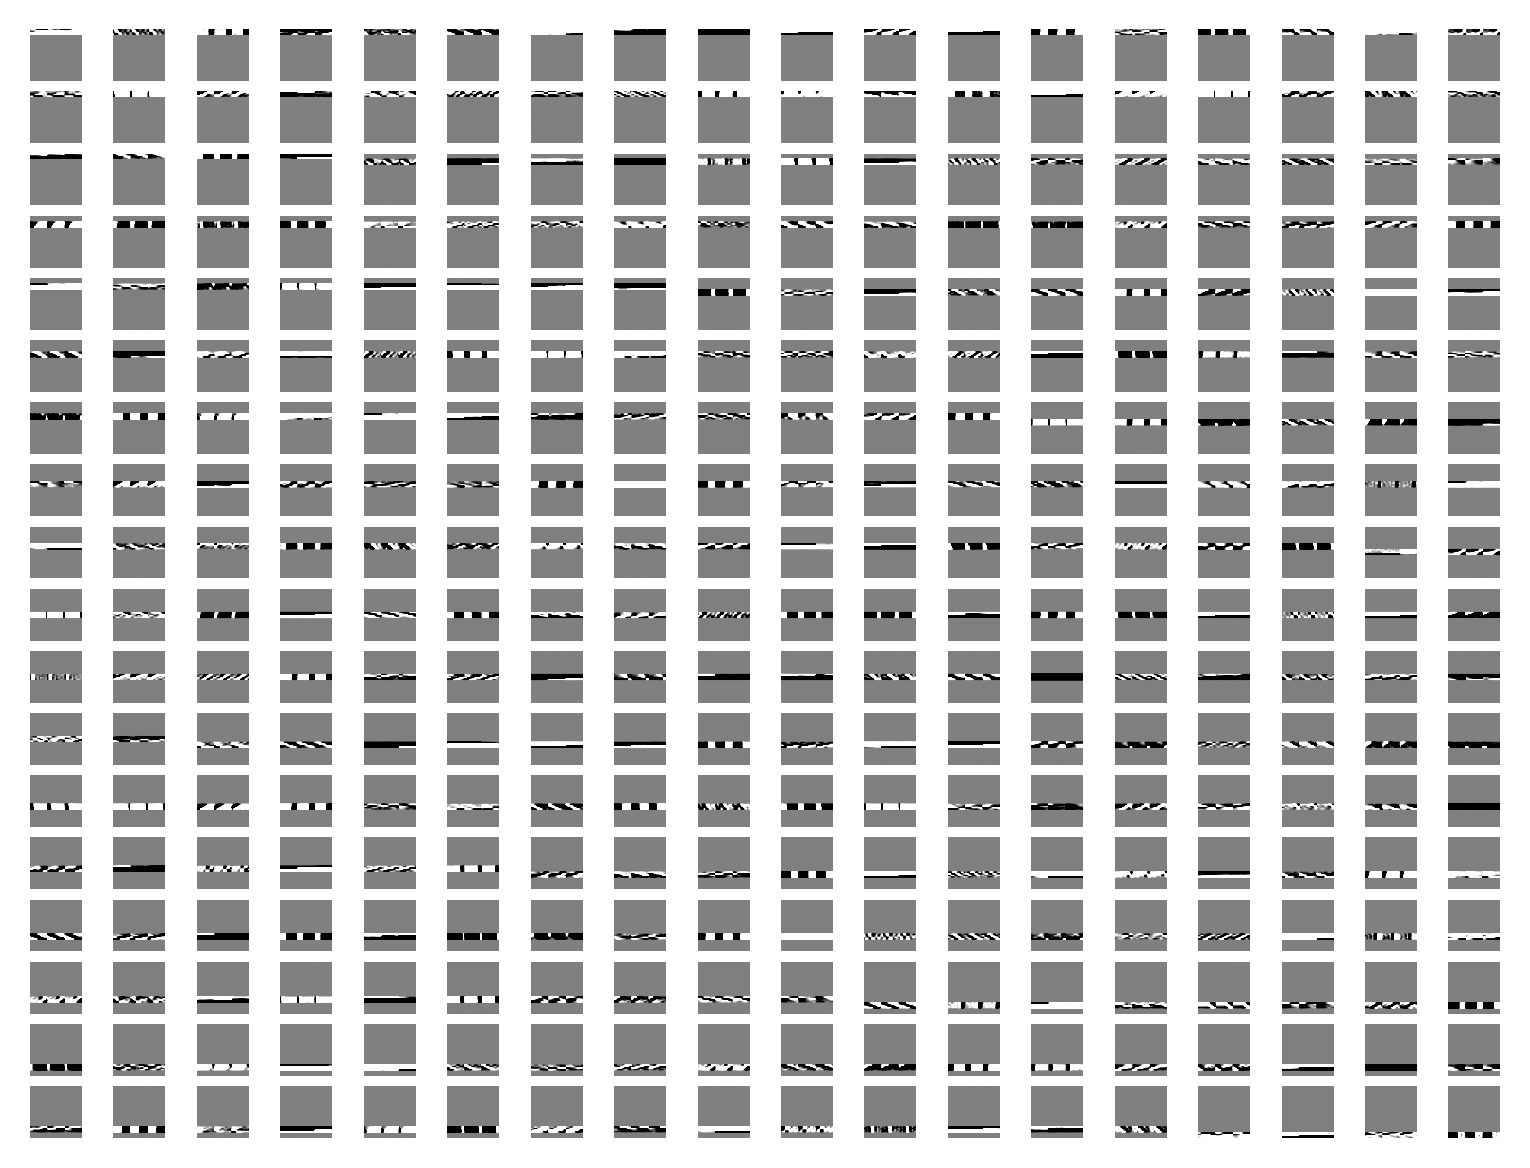

In [12]:
fig, axs = plt.subplots(nrows=18, ncols=18, dpi=300)
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(A[:, idx].reshape(36, 36), cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

In [14]:
B = np.load(basepath / "layer2_8_component_mappings.npy")
print(B.shape)

(360, 8)


In [16]:
model = pm.Model()
with model:
    image_data = pm.MutableData("image_data", np.zeros((1, A.shape[0])))
    g = pm.Exponential("g", 1, shape=B.shape[1])
    x = pm.LogNormal("x", mu=B @ g, sigma=1)
    i = pm.Normal("i", mu=A @ x, sigma=1, observed=image_data)

In [17]:
n_prior_samples = 100
with model:
    idata = pm.sample_prior_predictive(samples=n_prior_samples, random_seed=seed)

Sampling: [g, i, x]


In [26]:
images = idata['prior_predictive']['i'].data.squeeze(0).squeeze(1)
print(images.shape)

(100, 1296)


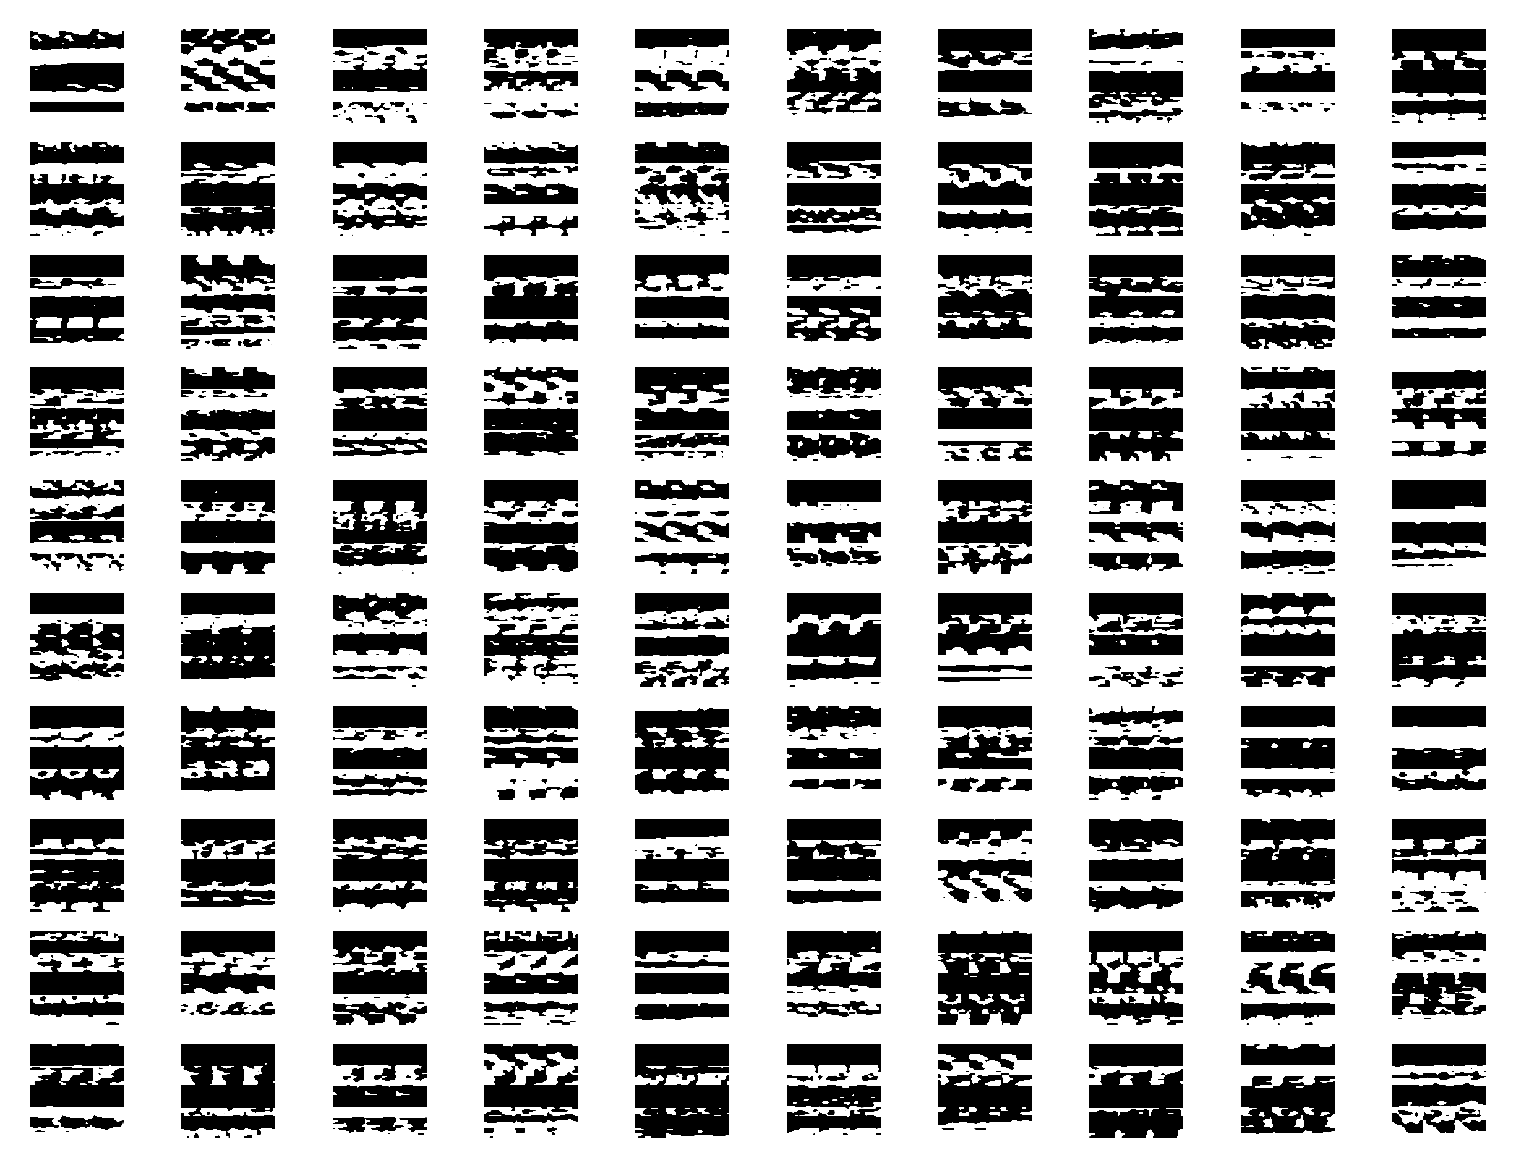

In [29]:
fig, axs = plt.subplots(nrows=10, ncols=10, dpi=300)
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(images[idx].reshape(36, 36), cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")